In [ ]:
### Install requirements
from pathlib import Path

REPOSITORY = "https://github.com/lmingari/olot-course.git"
REQUIREMENTS = "requirements-2p2.txt"

if not Path(REQUIREMENTS).exists():
    !git clone -q {REPOSITORY}
    %cd olot-course
    !pip install -q -r {REQUIREMENTS}

# 2.2 A multilayer perceptron (MLP) for classification

---

In this practice, we will use a simple **multilayer perceptron (MLP)** to classify the impact of tephra fallout at different locations on La Palma.

* We use the volcanic tephra deposition dataset from the 2021 Tajogaite Eruption on La Palma reported by [Shatto et al. (2024)][dataset]

* The dataset contains **415 in-situ field measurements** and **66 additional values** estimated from surface changes in areas unsuitable for in-situ sampling.

* The dataset is available on [Zenodo][zenodo]

| La Palma - Tephra depth measurements |
| --- |
| <img src="https://ars.els-cdn.com/content/image/1-s2.0-S2352340923009800-gr2.jpg" width=450/> |
| **Figure 1:** Tephra depth measurements from [Shatto et al. (2024)][dataset] |

[dataset]: https://doi.org/10.1016/j.dib.2023.109949
[zenodo]: https://doi.org/10.5281/zenodo.8338991
[paper-fig]: https://ars.els-cdn.com/content/image/1-s2.0-S2352340923009800-gr2.jpg

## Definition of impact classes

We define three classes of tephra fallout impact based on deposit thickness:

|Impact    | Thickness range   | Class |
|----------|:-----------------:|:-----:|
| Low      | < 1 mm            | 0     |
| Moderate | 1 - 100 mm        | 1     |
| High     | > 100 mm          | 2     |

> &#10004; **Goal:** \
>  Train an MLP to predict the impact class at a given location from its (lat, lon)

## Training configuration

In [1]:
conf = {
    'BATCH_SIZE': 16,
    'LEARNING_RATE': 1E-3,
    'NUM_EPOCHS': 400,
}

## &#128221; Example 2.3: Defining datasets

### Loading data
Let's load the tephra deposit measurements from `data/palma-deposit.csv`:

In [2]:
import pandas as pd
df = pd.read_csv('data/palma-deposit.csv')
df

,lat,lon,thickness_cm
0,28.577990,-17.877680,15.000
1,28.592690,-17.879120,20.000
2,28.598040,-17.880200,28.000
3,28.604890,-17.879860,80.000
4,28.603480,-17.885430,80.000
...,...,...,...
476,28.617246,-17.861019,212.702
477,28.617835,-17.863486,317.431
478,28.617206,-17.863197,460.203
479,28.614424,-17.860961,223.153


### Defining target categories

The dataset contains the deposit thickness in centimetres. We convert it into the three impact classes defined above:

In [3]:
## Define the categories

df['category'] = 0
df.loc[df['thickness_cm']>0.1,'category'] = 1
df.loc[df['thickness_cm']>10,'category']  = 2
df

,lat,lon,thickness_cm,category
0,28.577990,-17.877680,15.000,2
1,28.592690,-17.879120,20.000,2
2,28.598040,-17.880200,28.000,2
3,28.604890,-17.879860,80.000,2
4,28.603480,-17.885430,80.000,2
...,...,...,...,...
476,28.617246,-17.861019,212.702,2
477,28.617835,-17.863486,317.431,2
478,28.617206,-17.863197,460.203,2
479,28.614424,-17.860961,223.153,2


The resulting `category` column is our target variable.

### Check dataset balance

Let's check how many observations belong to each impact class:

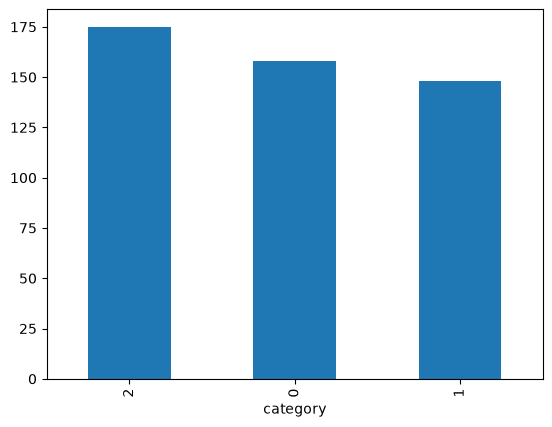

In [4]:
## Check dataset balance
_ = df['category'].value_counts().plot(kind='bar')

The classes are not equally represented. This is called **class imbalance** and can affect how well a classifier learns the different classes.

A classifier trained on an imbalanced dataset may favour the most frequent class!

### Define features and targets

In [4]:
features = ['lat','lon']
X = df[features].values
y = df['category'].values

### Split dataset

We split the observations into a training set and a validation set:

In [5]:
from modules.dataset import train_validation_split

X_train, X_val, y_train, y_val = train_validation_split( 
    X, y, train_fraction=0.8)

### Standardise input data

The two input features, latitude and longitude, have different numerical ranges.
We therefore standardise each feature to have approximately zero mean and unit variance:

$$
x \to \frac{x-\mu}{\sigma}
$$

Importantly, $\mu$ and $\sigma$ are calculated **using the training data only** and then applied to the validation data.

In [6]:
from torch.utils.data import DataLoader
from modules.dataset import Standardize, SupervisedDataset

# Compute normalization stats from training data only
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)

# Define transform
transform = Standardize(mean,std)

# Datasets
train_dataset = SupervisedDataset(X_train, y_train, transform=transform)
val_dataset   = SupervisedDataset(X_val, y_val, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=conf['BATCH_SIZE'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=conf['BATCH_SIZE'], shuffle=False)

## &#128221; Example 2.4: training the classifier

We use the `Trainer` defined in the previous practice. For classification, we only need to define how the loss is calculated for each batch.

In [7]:
from modules.training import Trainer

class ClassificationTrainer(Trainer):
    def get_loss(self, batch):
        X, y = batch
        prediction = self.model(X)

        return self.criterion(prediction, y)

The same training workflow can be used here:

In [8]:
import torch
import torch.nn as nn
from modules.model import MultiLayerPerceptron

model = MultiLayerPerceptron(
    in_dim  = 2, 
    hidden  = [64,64],
    out_dim = 3
)

trainer = ClassificationTrainer(
    model     = model,
    criterion = nn.CrossEntropyLoss(),
    optimizer = torch.optim.Adam(model.parameters(), lr=conf['LEARNING_RATE']),
)

In [9]:
history = trainer.fit(train_loader, val_loader, epochs=conf['NUM_EPOCHS'])

Epoch    1 | train loss: 0.9888 | val loss: 0.8540
Epoch  100 | train loss: 0.1883 | val loss: 0.1640
Epoch  200 | train loss: 0.1990 | val loss: 0.1257
Epoch  300 | train loss: 0.1651 | val loss: 0.1518
Epoch  400 | train loss: 0.1737 | val loss: 0.1614
Done!


In [22]:
history

,epoch,train_loss,val_loss
0,1,0.259652,0.255172
1,2,0.298164,0.260153
2,3,0.265881,0.254270
3,4,0.252143,0.247172
4,5,0.256626,0.236181
...,...,...,...
395,396,0.165345,0.178481
396,397,0.160508,0.155681
397,398,0.159966,0.159554
398,399,0.193440,0.155314


## Decision regions

In [23]:
import numpy as np
import xarray as xr

def get_decision_regions(model, transform):
    # Define the grid
    lat_min, lat_max = 28.4, 28.9
    lon_min, lon_max = -18.2, -17.65
    n_lat, n_lon = 220, 220

    lats = np.linspace(lat_min, lat_max, n_lat)
    lons = np.linspace(lon_min, lon_max, n_lon)

    lat_grid, lon_grid = np.meshgrid(
        lats, lons, indexing="ij"
    )

    # Prepare input coordinates
    X = np.column_stack([
        lat_grid.ravel(),
        lon_grid.ravel(),
    ])

    # Apply the same standardisation used for training
    X = transform(torch.from_numpy(X).float())

    # Predict impact class
    model.eval()
    with torch.no_grad():
        logits = model(X)
        impact = logits.argmax(dim=1)

    # Restore grid shape
    impact = impact.numpy().reshape(n_lat, n_lon)

    # Return as DataArray
    return xr.DataArray(
        impact,
        dims=("lat", "lon"),
        coords={
            "lat": lats,
            "lon": lons,
        },
        name="impact",
    )

In [25]:
data = get_decision_regions(model, transform)
data

<xarray.DataArray 'impact' (lat: 220, lon: 220)> Size: 387kB
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], shape=(220, 220))
Coordinates:
  * lat      (lat) float64 2kB 28.4 28.4 28.4 28.41 ... 28.89 28.9 28.9 28.9
  * lon      (lon) float64 2kB -18.2 -18.2 -18.19 ... -17.66 -17.65 -17.65

In [41]:
from modules.plotting import DecisionBoundariesPlotter

plotter = DecisionBoundariesPlotter(data)

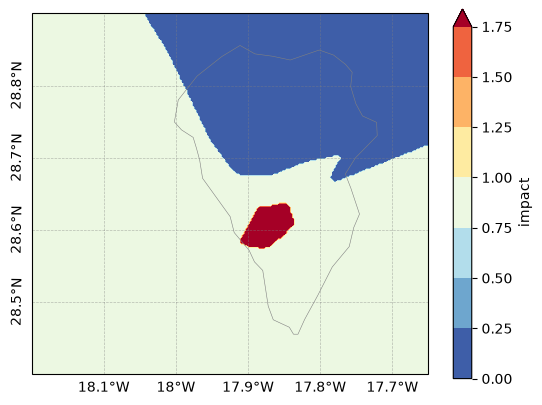

In [42]:
plotter.contourf()

In [40]:
import importlib
import modules.plotting

# Force reload the module
importlib.reload(modules.plotting)

<module 'modules.plotting' from '/home/lmingari/repositories/olot-course/modules/plotting.py'>

In [16]:
from modules.plotting import plot_decision_regions

fig, ax = plot_decision_regions(model, transform)

for category, label, color in [(0,'Low','b'), (1,'Moderate','y'), (2,'High','r')]:
    df.loc[df.category==category].plot.scatter(
        x = 'lon', y = 'lat', 
        c     = color,
        s     = 5,
        alpha = 0.5,
        label = label,
        ax = ax)

fig.set_size_inches(6, 8)

NameError: name 'create_map' is not defined

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    """
    Performs one complete training epoch over the dataset.
    
    Args:
        model: The neural network model to be trained
                
        loader: DataLoader that provides batches of training data. 
            Each iteration yields a batch of inputs and targets
        
        criterion: Loss function used to compute the training loss (e.g., nn.MSELoss).
            Takes model predictions and targets as input
        
        optimizer: Optimization algorithm used to update model parameters (e.g., Adam, SGD).
    
    Returns:
        Returns training metrics (average loss and accuracy for the epoch)
    """
    
    # Set training mode
    model.train()
    
    total_loss = 0.0
    corrects   = 0

    # Mini-batch loop
    for xb, yb in loader:
        # Model prediction
        logits = model(xb)
        # Compute loss
        loss = criterion(logits, yb)

        # Update gradients
        optimizer.zero_grad()        
        loss.backward()

        # Update parameters
        optimizer.step()

        # Predict category
        predicted_category = torch.argmax(logits,dim=1)

        # Update metrics
        total_loss += loss.item()
        corrects += (predicted_category == yb).sum().item()

    # Return average loss and accuracy (%)
    return total_loss / len(loader.dataset), 100 * corrects / len(loader.dataset)

#### Plotting the distribution of measurements

In [ ]:
from helper_plot import create_map

fig, ax = create_map()

for target, label, color in [(0,'Low','b'), (1,'Moderate','y'), (2,'High','r')]:
    df.loc[df.category==target].plot.scatter(
        x='lon', y='lat', 
        c=color,
        s=4,
        alpha=0.5,
        label = label,
        ax = ax)

#### Splitting datasets

## Training loop

In [ ]:
train_losses = []
train_accs   = []
val_losses   = []
val_accs     = []

for epoch in range(conf['NUM_EPOCHS']):
    train_loss, train_acc = train_epoch(model, loader_train, criterion, optimizer)
    val_loss,   val_acc   = evaluate_epoch(model, loader_val, criterion)

    # Store current losses/accuracies
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Print log
    if epoch%10 == 0:
        print(f"Epoch {epoch+1:03d}:")
        print(f"Train loss (accuracy): {train_loss:.4f} ({train_acc:.2f}%) || Validation loss (accuracy): {val_loss:.4f} ({val_acc:.2f}%)")

In [ ]:
fig, axs = plt.subplots(ncols = 2, figsize=(12,5))

axs[0].plot(train_losses, label = 'Training loss')
axs[0].plot(val_losses,   label = 'Validation loss')

axs[1].plot(train_accs, label = "Training accuracy")
axs[1].plot(val_accs,   label = "Validation accuracy")

axs[0].set(ylabel = 'Average loss', xlabel = 'Epoch')
axs[1].set(ylabel = 'Accuracy (%)', xlabel = 'Epoch')

for ax in axs: ax.legend()

## Decision regions

In [17]:
from helper_plot import plot_decision_regions

fig, ax = plot_decision_regions(model, transform)

for category, label, color in [(0,'Low','b'), (1,'Moderate','y'), (2,'High','r')]:
    df.loc[df.category==category].plot.scatter(
        x = 'lon', y = 'lat', 
        c     = color,
        s     = 5,
        alpha = 0.5,
        label = label,
        ax = ax)

fig.set_size_inches(6, 8)

ValueError: cannot convert float NaN to integer

Error in callback <function _draw_all_if_interactive at 0x7f9bea21c040> (for post_execute), with arguments args (),kwargs {}:


GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

<Figure size 640x480 with 2 Axes>

> &#9998; **Exercise 1:** <br>
> * Redefine the model class `Classifier` by removing the ReLU activation functions
> * How are the decision regions modified?

> &#9998; **Exercise 2:** <br>
> Increase overfitting by:
> - Decreasing the learning rate ($\eta = 10^{-4}$)
> - Increasing the number of epochs ($N=1200$)
> - Adding more neurons or more layers